In [1]:
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
from datetime import datetime

# Set GPU device
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
jax.config.update('jax_platform_name', 'gpu')


In [2]:
!nvidia-smi


Tue Jun 17 20:25:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           Off |   00000000:1A:00.0 Off |                    0 |
| N/A   36C    P0             44W /  300W |       1MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from config_generator import load_config, generate_default_config
from power_spectrum import setup_power_spectrum
from data_loader import setup_data_loaders, load_observation_data, load_simulation_data
from muse_problem import create_muse_problem
from optimization import MuseOptimizer, CovarianceEstimator, run_full_analysis

In [4]:
try:
    config = load_config("p3d_config.yaml")
    print("Loaded existing configuration")
except FileNotFoundError:
    print("Creating default configuration...")
    config = generate_default_config()
    
print(f"Running analysis with:")
print(f"  Box size: {config['simulation']['box_size']} Mpc/h")
print(f"  Grid size: {config['simulation']['n_cells']}^3")
print(f"  Redshift: {config['simulation']['redshift']}")
print(f"  Max steps: {config['optimization']['max_steps']}")


Creating default configuration...
Running analysis with:
  Box size: 150 Mpc/h
  Grid size: 150^3
  Redshift: 2.0
  Max steps: 100


In [5]:
# Setup power spectrum
print("\nSetting up power spectrum...")
power_data = setup_power_spectrum(config)



Setting up power spectrum...
Loaded model array shape: (66, 3), kmax: 3.2255218029022217


In [6]:
print("Loading data...")
data_loaders = setup_data_loaders(config)
obs_data = load_observation_data(config)
sim_data = load_simulation_data(config)


Loading data...
Loaded naa: (9591600,)
Loaded kernel: (1, 1198950, 8)
Loaded skewers_skn: (1198950,)
Loaded skewers_dla: (1198950,)
Loaded skewers_fin: (1198950, 3)
Loaded simulation data: (154, 154, 154)
load existing lya map
Loaded naa: (9591600,)
Loaded kernel: (1, 1198950, 8)
Loaded skewers_skn: (1198950,)
Loaded skewers_dla: (1198950,)
Loaded skewers_fin: (1198950, 3)
Loaded simulation data: (154, 154, 154)


In [ ]:
# try different initial conditions
perturbation_scale_array = np.arange(0.1,1.1,0.1)
for initial_seq in range(len(perturbation_scale_array)):
    # Create MUSE problem
    print("Creating MUSE problem...")
    problem = create_muse_problem(power_data, data_loaders, config)
    # problem = create_muse_problem(power_data, data_loaders, config, jit=True)
    problem.set_x(data_loaders['lya']['map_lya_sim'])
    
    key = jax.random.PRNGKey(100)
    x_data = problem.sample_x_z(key, problem.tf_cut_flat)[0]
    # Setup initial conditions
    start_point = problem.get_starting_point(perturbation_scale=perturbation_scale_array[initial_seq])

    # Initialize random key
    rng = jax.random.PRNGKey(config['random_seed'])
    
    # Run complete analysis
    print(f"\nStarting MUSE analysis at {datetime.now()}")
    print("="*50)
    
    result = run_full_analysis(problem, config, x_data, start_point, rng)
    np.save("../results/initial_condition_scale_%.2f.npy"%(perturbation_scale_array[initial_seq]),result)

Creating MUSE problem...

Starting MUSE analysis at 2025-06-17 20:26:08.795945
Starting Full P3D MUSE Analysis

Phase 1: Parameter Optimization
----------------------------------------
Starting MUSE optimization...
Parameters: maxsteps=200, nsims=10
Optimization step: 1, learning rate: 0.700000


In [7]:
# Create MUSE problem
print("Creating MUSE problem...")
problem = create_muse_problem(power_data, data_loaders, config)
# problem = create_muse_problem(power_data, data_loaders, config, jit=True)
problem.set_x(data_loaders['lya']['map_lya_sim'])

key = jax.random.PRNGKey(100)
x_data = problem.sample_x_z(key, problem.tf_cut_flat)[0]
# Setup initial conditions
start_point = problem.get_starting_point(perturbation_scale=0.01)



Creating MUSE problem...


In [8]:
# Initialize random key
rng = jax.random.PRNGKey(config['random_seed'])

# Run complete analysis
print(f"\nStarting MUSE analysis at {datetime.now()}")
print("="*50)


Starting MUSE analysis at 2025-06-17 18:29:04.569278


In [ ]:
result = run_full_analysis(problem, config, x_data, start_point, rng)

Starting Full P3D MUSE Analysis

Phase 1: Parameter Optimization
----------------------------------------
Starting MUSE optimization...
Parameters: maxsteps=200, nsims=10
Optimization step: 1, learning rate: 0.700000


In [11]:
np.save("../results/initial_condition_scale_%.2f.npy"%(0.01),result)

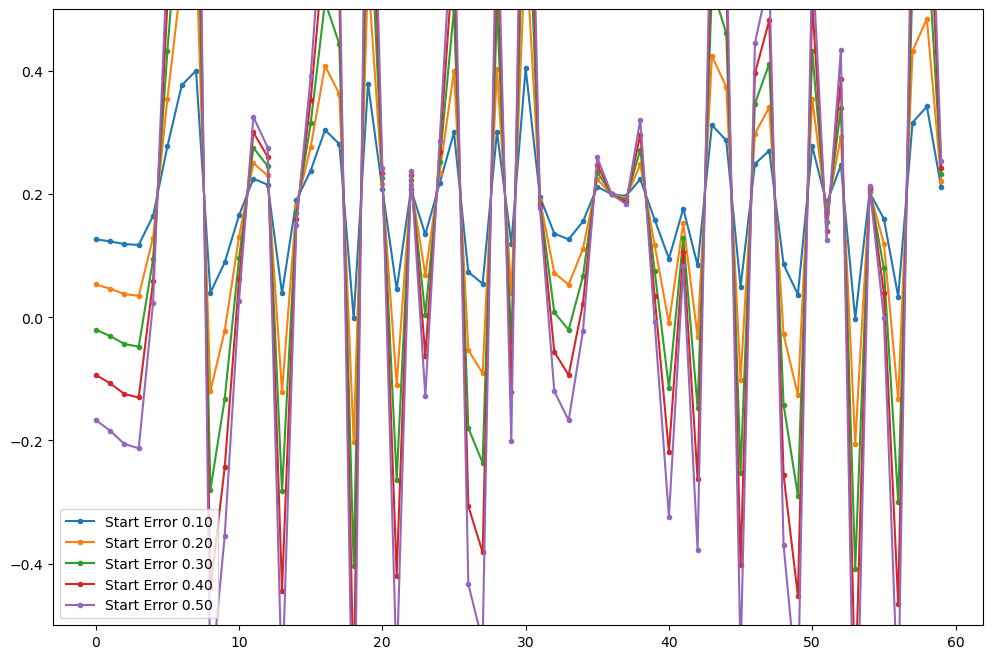

In [31]:
# test the initial condition
fig,ax = plt.subplots(figsize=(12, 8))

perturbation_scale_array = np.arange(0.1,1.1,0.1)
for initial_seq in range(len(perturbation_scale_array)):
    result =  np.load("../results/initial_condition_scale_%.2f.npy"%(perturbation_scale_array[initial_seq]),allow_pickle=True).item() 

    if result["covariance_results"]["success"]:

        tf_cut_flat = result["θ_fiducial"].flatten()
        θ = result["θ_final"].flatten()
        start_point = result["start_point"].flatten()
        
        Σ = result["covariance_results"]["covariance"]
        Σ_inv = result["covariance_results"]["precision"]
        
        ax.plot((start_point - tf_cut_flat) / tf_cut_flat, ".-", label="Start Error %.2f"%(perturbation_scale_array[initial_seq]))
        # plt.errorbar(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,yerr = np.abs(np.sqrt(np.diag(Σ)) / tf_cut_flat))
        # plt.plot(np.arange(len(tf_cut_flat)),np.arange(len(tf_cut_flat))*0.0,"k:")
        ax.set_ylim(-0.5,0.5)
plt.legend()

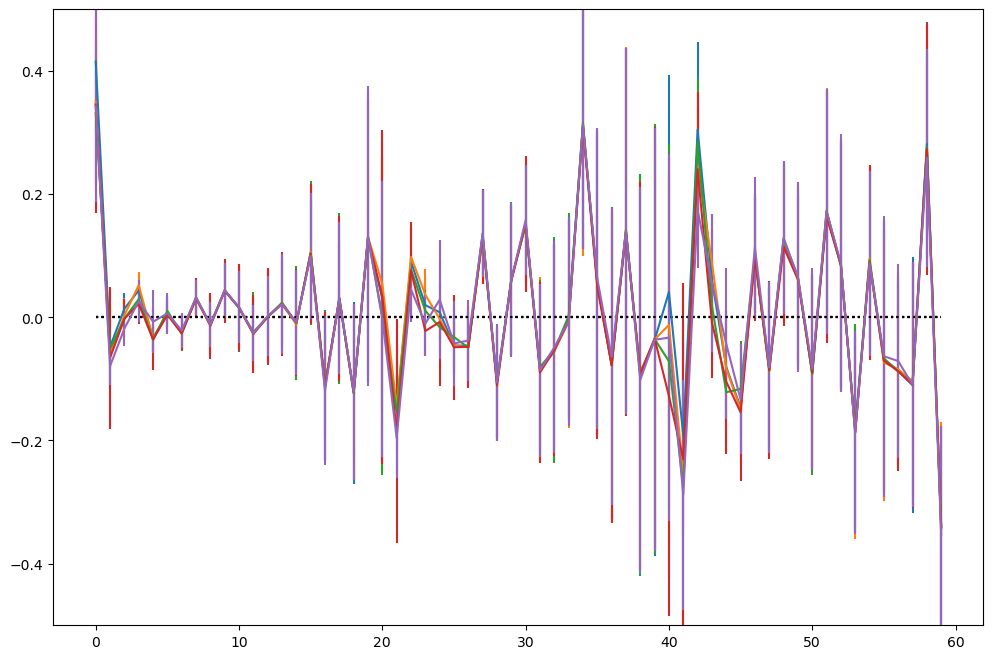

In [32]:
# test the initial condition
fig,ax = plt.subplots(figsize=(12, 8))

perturbation_scale_array = np.arange(0.1,1.1,0.1)
for initial_seq in range(len(perturbation_scale_array)):
    result =  np.load("../results/initial_condition_scale_%.2f.npy"%(perturbation_scale_array[initial_seq]),allow_pickle=True).item() 

    if result["covariance_results"]["success"]:

        tf_cut_flat = result["θ_fiducial"].flatten()
        θ = result["θ_final"].flatten()
        start_point = result["start_point"].flatten()
        
        Σ = result["covariance_results"]["covariance"]
        Σ_inv = result["covariance_results"]["precision"]
        
        plt.errorbar(np.arange(len(tf_cut_flat)),(θ-tf_cut_flat)/tf_cut_flat,yerr = np.abs(np.sqrt(np.diag(Σ)) / tf_cut_flat))
        plt.plot(np.arange(len(tf_cut_flat)),np.arange(len(tf_cut_flat))*0.0,"k:")
        ax.set_ylim(-0.5,0.5)


Running MUSE optimization...
Starting MUSE optimization...
Parameters: maxsteps=200, nsims=10
Optimization step: 1, learning rate: 0.700000
Optimization step: 2, learning rate: 0.700000
Optimization step: 3, learning rate: 0.700000
Optimization step: 4, learning rate: 0.665000
Optimization step: 5, learning rate: 0.665000
Optimization step: 6, learning rate: 0.665000


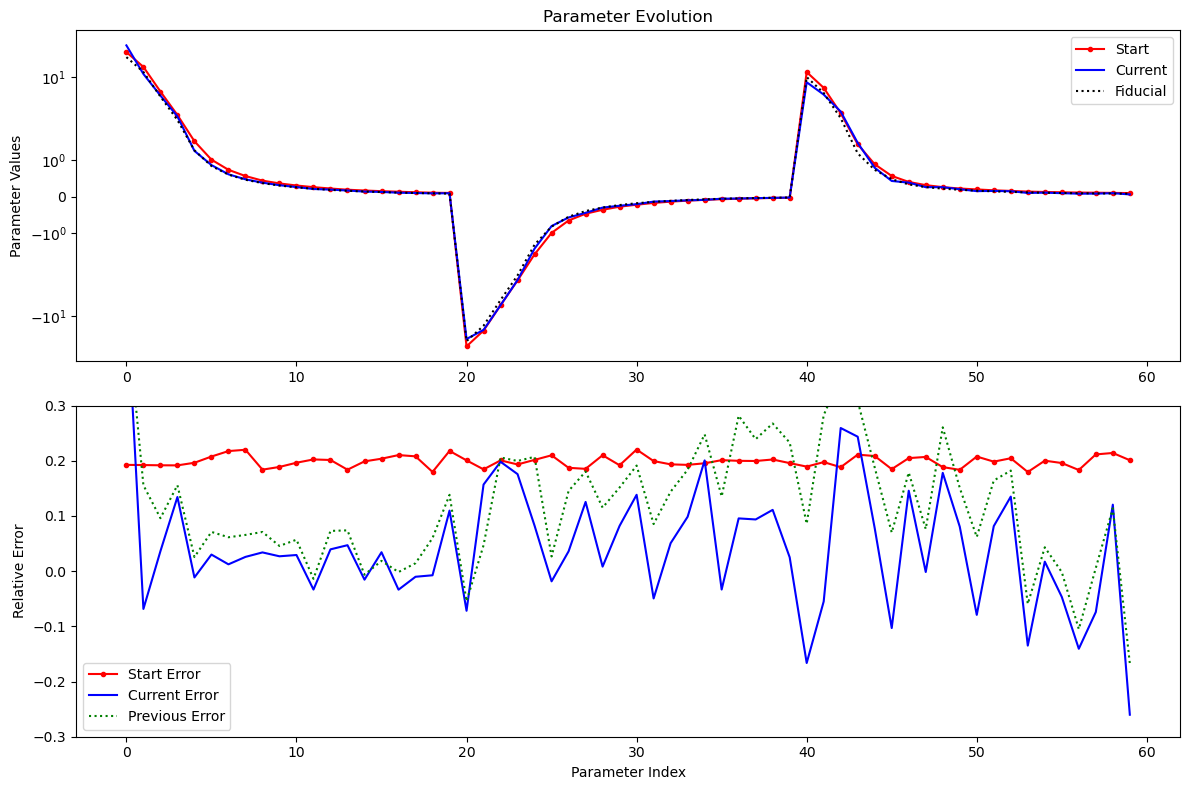

Optimization step: 7, learning rate: 0.631750
Optimization step: 8, learning rate: 0.631750
Optimization step: 9, learning rate: 0.631750
Optimization step: 10, learning rate: 0.600162
Optimization step: 11, learning rate: 0.600162
Optimization step: 12, learning rate: 0.600162


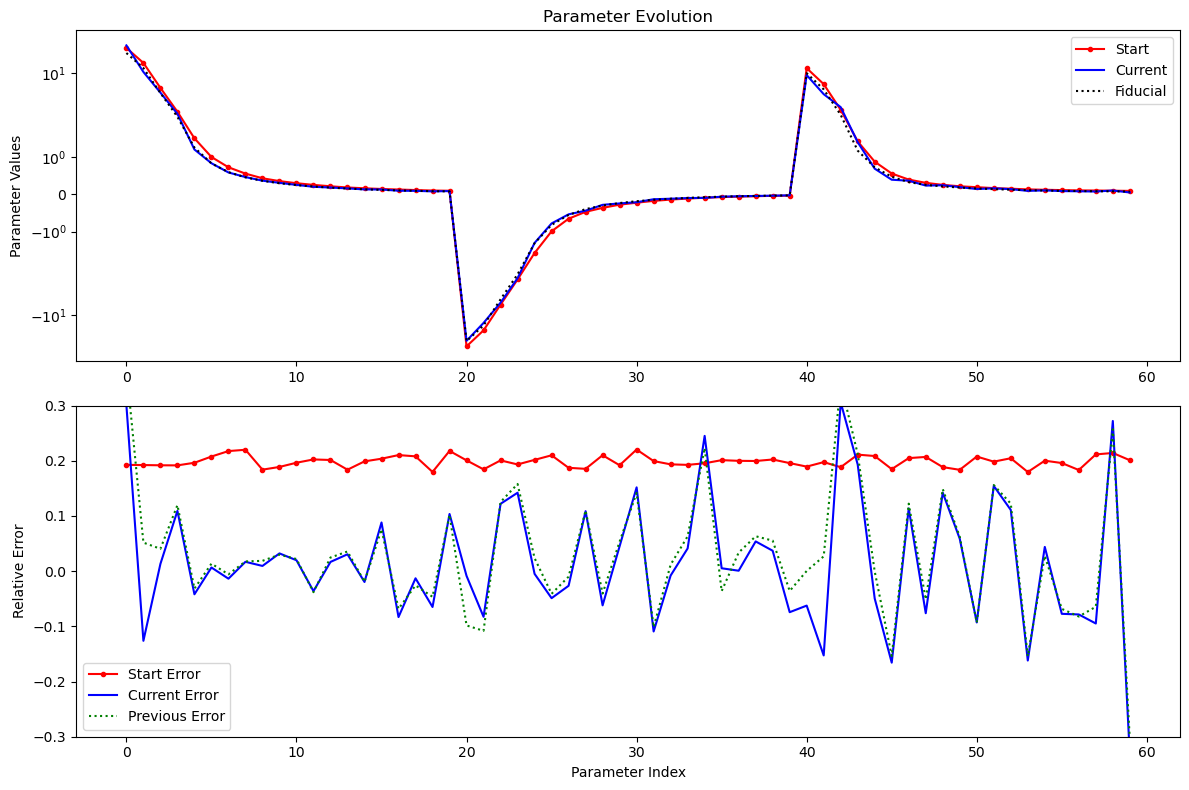

Optimization step: 13, learning rate: 0.570154
Optimization step: 14, learning rate: 0.570154
Optimization step: 15, learning rate: 0.570154
Optimization step: 16, learning rate: 0.541647
Optimization step: 17, learning rate: 0.541647
Optimization step: 18, learning rate: 0.541647


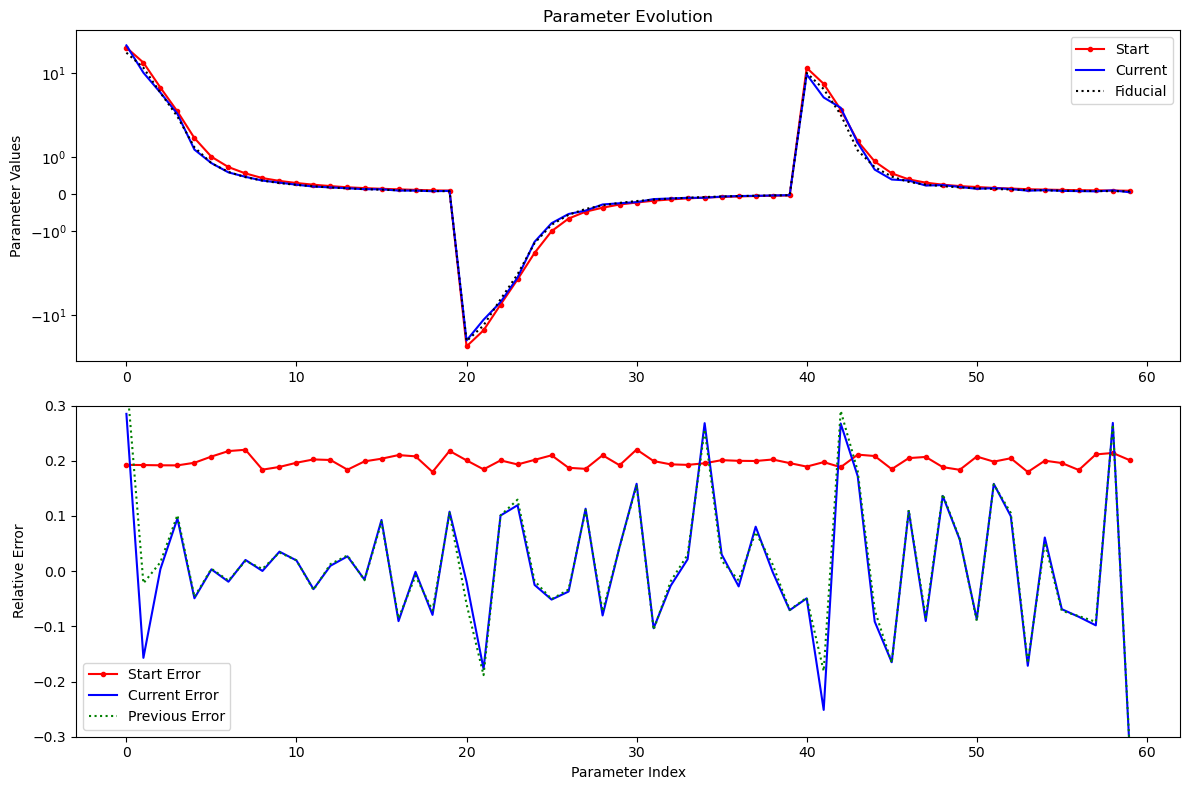

Optimization step: 19, learning rate: 0.514564
Optimization step: 20, learning rate: 0.514564
Optimization step: 21, learning rate: 0.514564
Optimization step: 22, learning rate: 0.488836
Optimization step: 23, learning rate: 0.488836
Optimization step: 24, learning rate: 0.488836


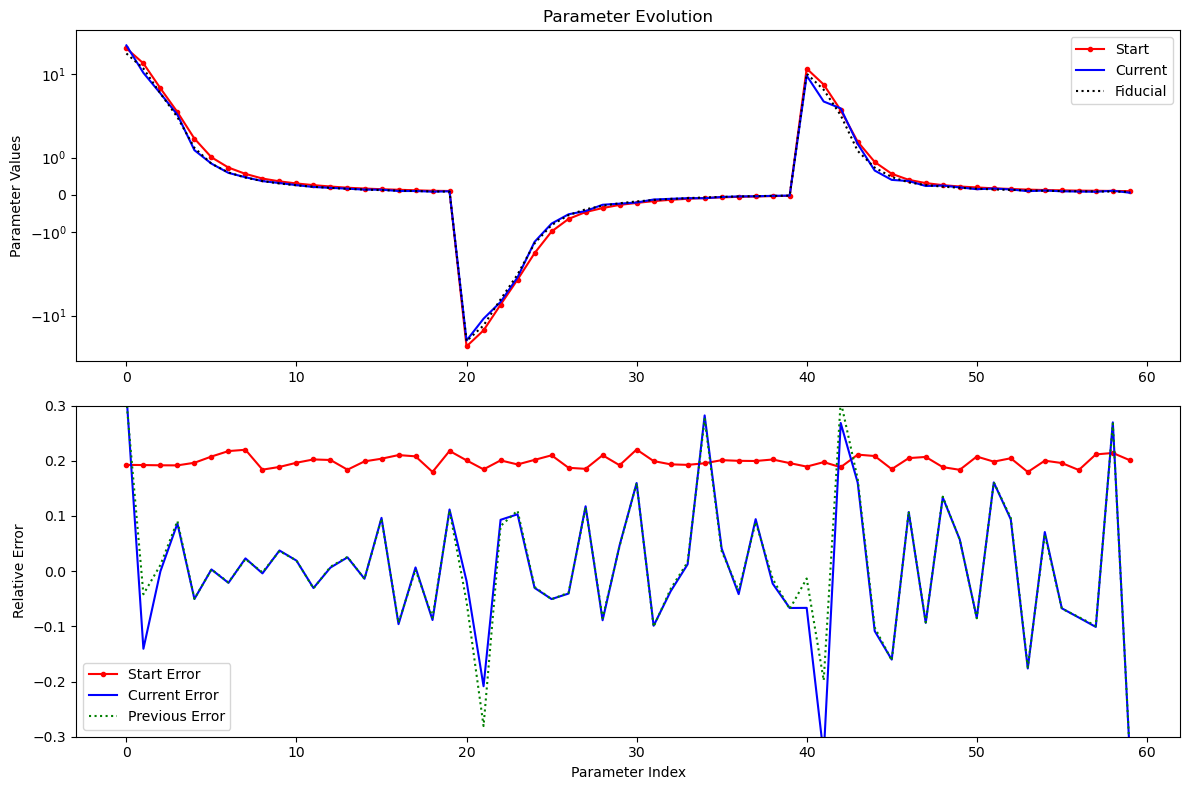

Optimization step: 25, learning rate: 0.464394
Optimization step: 26, learning rate: 0.464394
Optimization step: 27, learning rate: 0.464394
Optimization step: 28, learning rate: 0.441175
Optimization step: 29, learning rate: 0.441175
Optimization step: 30, learning rate: 0.441175


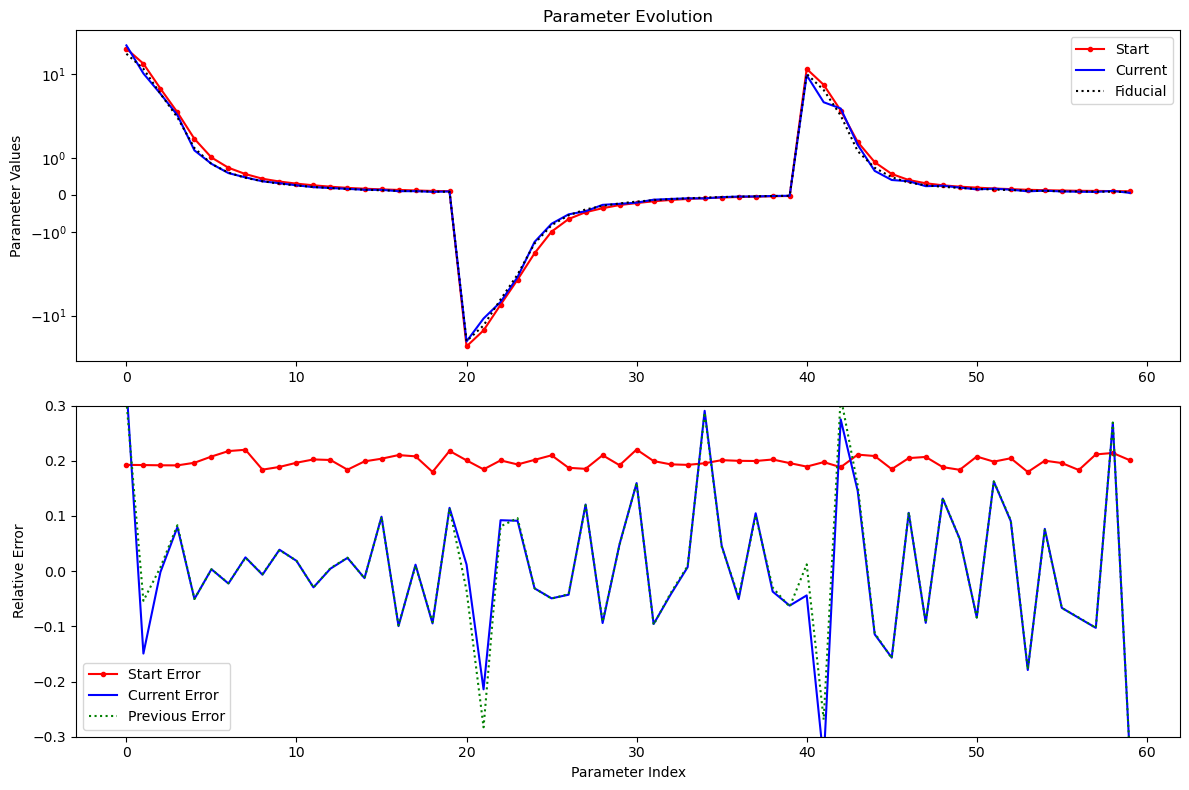

Optimization step: 31, learning rate: 0.419116
Optimization step: 32, learning rate: 0.419116


KeyboardInterrupt: 

In [9]:
# Run optimization
print("Running MUSE optimization...")
optimizer = MuseOptimizer(problem, config)
opt_results = optimizer.run_optimization(x_data, start_point, rng)


In [ ]:
θ_final = opt_results['θ_final']
s_MAP_sims = opt_results['s_MAP_sims']
z_MAP_sims = [z for z in opt_results['ẑs'] if z is not None]

estimator = CovarianceEstimator(problem, config)

# Compute score covariance
rng, subkey = jax.random.split(rng)
J = estimator.get_score_covariance(
    θ=θ_final,
    s_MAP_sims=s_MAP_sims,
    rng=subkey,
    nsims=config.get('fisher', {}).get('n_sims_fisher', 50)
)

# Compute Fisher matrix
rng, subkey = jax.random.split(rng)
H = estimator.get_fisher_matrix(
    θ=θ_final,
    z_MAP_sims=z_MAP_sims,
    rng=subkey,
    nsims=config.get('fisher', {}).get('n_sims_hessian', 50)
)

# Final covariance
cov_results = estimator.compute_covariance(θ_final, J, H)


In [ ]:
H_prior = cov_results["prior_hessian"]
Σ_inv = cov_results["precision"]
Σ = cov_results["covariance"]


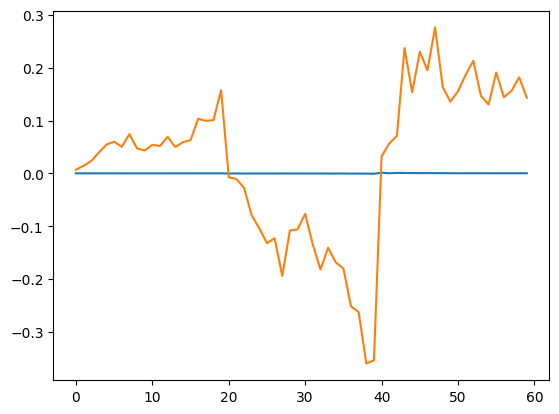

In [14]:
import matplotlib.pyplot as plt
plt.plot(1/np.sqrt(np.diag(Σ_inv))/problem.tf_cut_flat)
plt.plot(np.sqrt(np.diag(Σ))/problem.tf_cut_flat)

# plt.plot(abs((start_point-θ)/problem.tf_cut_flat),"k:")

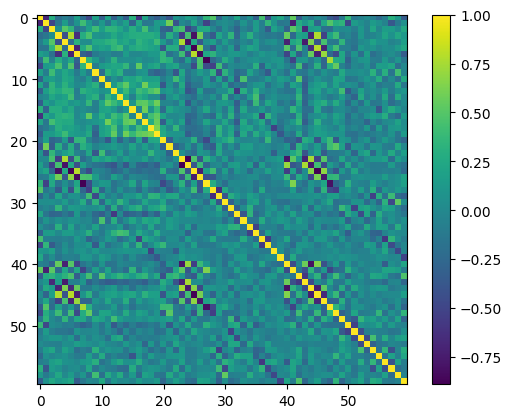

In [17]:
# covariance matrix
Σ_iijj = np.zeros(Σ_inv.shape)
for i in range(Σ_inv.shape[0]):
    for j in range(Σ_inv.shape[1]):
       Σ_iijj[i,j] = np.sqrt(Σ[i,i]*Σ[j,j])
plt.imshow(Σ/Σ_iijj)
plt.colorbar()

In [ ]:
def save_results(results, config):
    """Save analysis results"""
    output_dir = config.get('output_dir', './results')
    os.makedirs(output_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save parameter estimates

        
    # Save history

    print(f"Results saved to {output_dir}")


In [ ]:
save_results(results, config)
